# 6.3 Ejercicio 3: Agrupación o Clustering

## Dataset: `clave_F_agrupacion.csv`


## Paso 0. Importación de librerías

In [1]:

import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## Paso 1. Carga y exploración inicial del dataset


In [11]:

url = "https://raw.githubusercontent.com/NixonAV/Parcial4AyalaNixon2509112022/refs/heads/main/Archivos/clave_F_agrupacion.csv"
df = pd.read_csv(url, encoding="utf-8-sig")

print("Dimensiones del dataset:", df.shape)
display(df.head(10))


Dimensiones del dataset: (250, 8)


,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,F-R0218,47,1028,5.48,63.75,3.04,5,13
1,F-R0008,35,733,1.41,25.26,5.60,3,3
2,F-R0082,36,985,9.98,98.95,7.11,3,27
3,F-R0009,30,473,1.61,5.00,5.76,12,1
4,F-R0244,39,978,2.57,27.35,3.31,4,10
5,F-R0142,50,1559,11.70,175.62,7.97,0,37
6,F-R0219,40,819,4.33,38.50,4.64,4,7
7,F-R0077,46,1110,5.75,260.00,7.34,2,9
8,F-R0249,41,1105,5.22,69.18,6.07,4,27
9,F-R0165,58,1663,7.41,148.01,8.49,0,35


In [12]:

print("Tipos de datos:")
display(df.dtypes.to_frame("tipo_de_dato"))

numeric_cols = df.select_dtypes(include="number").columns.tolist()
print("Variables numéricas identificadas:")
print(numeric_cols)

print("\nValores nulos por columna:")
display(df.isnull().sum().to_frame("nulos"))

print("\nRegistros duplicados:", df.duplicated().sum())

summary = df[numeric_cols].describe().T
summary["rango"] = summary["max"] - summary["min"]
summary["missing"] = df[numeric_cols].isnull().sum()
display(summary)


Tipos de datos:


,tipo_de_dato
registro_id,object
edad,int64
ingresos,int64
frecuencia_uso,float64
gasto_promedio,float64
satisfaccion,float64
reclamos,int64
antiguedad_meses,int64


Variables numéricas identificadas:
['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']

Valores nulos por columna:


,nulos
registro_id,0
edad,0
ingresos,0
frecuencia_uso,0
gasto_promedio,0
satisfaccion,1
reclamos,0
antiguedad_meses,0



Registros duplicados: 0


,count,mean,std,min,25%,50%,75%,max,rango,missing
edad,250.0,39.244000,10.016877,18.00,32.0000,39.000,47.0000,66.00,48.00,0
ingresos,250.0,1063.948000,429.301685,300.00,747.2500,983.500,1342.2500,2900.00,2600.00,0
frecuencia_uso,250.0,5.435960,3.053921,0.00,2.7275,5.475,7.8325,13.36,13.36,0
gasto_promedio,250.0,84.714200,49.368022,5.00,46.6525,72.315,119.7150,260.00,255.00,0
satisfaccion,249.0,6.872209,1.950381,2.28,5.1800,7.280,8.4800,10.00,7.72,1
reclamos,250.0,2.408000,1.986282,0.00,1.0000,2.000,4.0000,12.00,12.00,0
antiguedad_meses,250.0,18.332000,13.076458,1.00,9.0000,16.000,28.0000,56.00,55.00,0


In [5]:

# Revisión de valores atípicos con criterio IQR
outlier_data = []

for c in numeric_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = int(((df[c] < lim_inf) | (df[c] > lim_sup)).sum())
    outlier_data.append({
        "variable": c,
        "limite_inferior": round(lim_inf, 3),
        "limite_superior": round(lim_sup, 3),
        "atipicos": n_out
    })

outliers_df = pd.DataFrame(outlier_data)
display(outliers_df)


,variable,limite_inferior,limite_superior,atipicos
0,edad,9.500,69.500,0
1,ingresos,-145.250,2234.750,1
2,frecuencia_uso,-4.930,15.490,0
3,gasto_promedio,-62.941,229.309,1
4,satisfaccion,0.230,13.430,0
5,reclamos,-3.500,8.500,1
6,antiguedad_meses,-19.500,56.500,0


## Paso 2. Selección de variables para clustering

Se seleccionan todas las variables numéricas del dataset excepto `cliente_id`, porque el objetivo es agrupar clientes por comportamiento y perfil, no por un identificador.

Variables usadas:
- `edad`
- `ingresos`
- `frecuencia_uso`
- `gasto_promedio`
- `satisfaccion`
- `reclamos`
- `antiguedad_meses`

**Justificación:** estas variables describen capacidad de compra, nivel de interacción, experiencia del cliente y fricción en el servicio.  
Antes de aplicar K-Means es necesario normalizar, porque cada variable está en escalas distintas.


In [13]:

# Variables elegidas para clustering
cluster_cols = numeric_cols.copy()

df_cluster = df[cluster_cols].copy()

# Imputación simple para manejar valores faltantes
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(df_cluster)

# Escalado de variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Datos preparados correctamente.")
print("Variables usadas:", cluster_cols)
print("Matriz escalada:", X_scaled.shape)


Datos preparados correctamente.
Variables usadas: ['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']
Matriz escalada: (250, 7)


## Paso 3. Método del codo para seleccionar el número de grupos


,k,inercia,silhouette
0,2,858.240493,0.418496
1,3,585.762347,0.382187
2,4,449.856702,0.384990
3,5,431.404369,0.300539
4,6,408.630716,0.260531
5,7,391.731100,0.177412
6,8,376.724510,0.181416


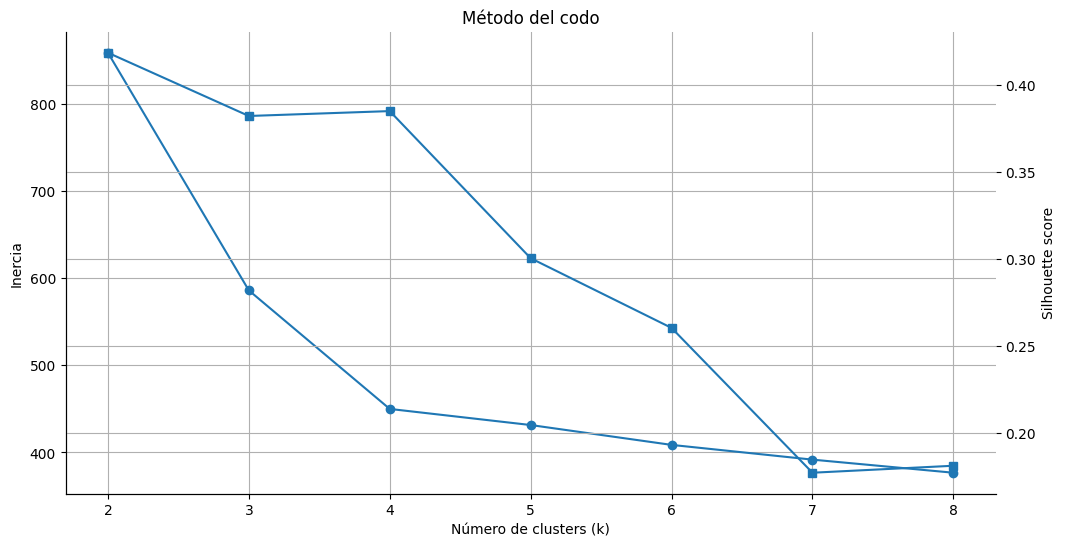

In [7]:

inertias = []
silhouettes = []
ks = range(2, 9)

for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

elbow_df = pd.DataFrame({
    "k": list(ks),
    "inercia": inertias,
    "silhouette": silhouettes
})
display(elbow_df)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(list(ks), inertias, marker="o")
ax1.set_xlabel("Número de clusters (k)")
ax1.set_ylabel("Inercia")
ax1.set_title("Método del codo")

ax2 = ax1.twinx()
ax2.plot(list(ks), silhouettes, marker="s")
ax2.set_ylabel("Silhouette score")

plt.show()


## Paso 4. Aplicación de K-Means

A partir de la gráfica del codo, se elige **k = 4** porque ofrece una buena separación de grupos y mantiene una interpretación de negocio clara.


In [8]:

k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters_raw = kmeans.fit_predict(X_scaled)

df_result = df.copy()
df_result["cluster"] = clusters_raw

# Resumen de clusters
profile = df_result.groupby("cluster")[cluster_cols].mean().round(2)
sizes = df_result["cluster"].value_counts().sort_index().to_frame("cantidad")
profile = profile.join(sizes)

display(profile)

print("Silhouette score final:", round(silhouette_score(X_scaled, clusters_raw), 4))


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cantidad
cluster,,,,,,,,
0,28.11,649.75,2.06,35.34,5.80,3.02,7.27,63
1,36.09,1078.16,6.48,85.67,8.18,1.22,18.00,68
2,42.28,861.21,3.94,59.39,4.48,5.04,12.46,57
3,51.23,1655.63,9.09,157.12,8.71,0.68,35.34,62


Silhouette score final: 0.385


## Paso 5. Visualización de los grupos

Para visualizar los clusters en dos dimensiones se usa **PCA**, que reduce las variables a dos componentes principales manteniendo la mayor variabilidad posible.


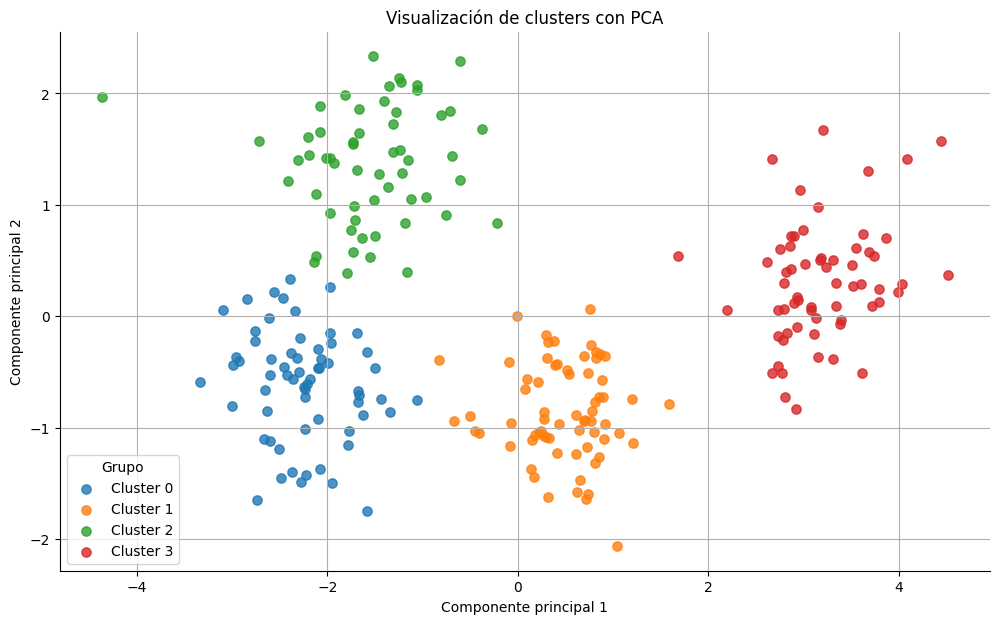

Varianza explicada por PCA: 0.8099


In [9]:

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = clusters_raw

fig, ax = plt.subplots(figsize=(12, 7))
for c in sorted(pca_df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == c]
    ax.scatter(subset["PC1"], subset["PC2"], s=45, alpha=0.8, label=f"Cluster {c}")

ax.set_title("Visualización de clusters con PCA")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.legend(title="Grupo")
plt.show()

print("Varianza explicada por PCA:", round(pca.explained_variance_ratio_.sum(), 4))


In [10]:
# Tabla de interpretación de clusters basada en el perfil promedio
cluster_mean = df_result.groupby("cluster")[cluster_cols].mean().round(2)

interpretacion = pd.DataFrame({
    "cluster": cluster_mean.index,
    "interpretacion_posible": [
        "Clientes jóvenes, con ingresos bajos, baja frecuencia de uso y consumo reducido.",
        "Clientes de mayor valor: usan más el servicio, gastan más y muestran alta satisfacción.",
        "Clientes con más reclamos y satisfacción más baja; requieren atención prioritaria.",
        "Clientes VIP o leales: mayores ingresos, alta antigüedad, uso intenso y muy buena satisfacción."
    ],
    "acciones_negocio": [
        "Usar promociones de activación, ofertas de bienvenida y campañas para aumentar uso y compra.",
        "Lanzar programas de fidelización, cross-selling y beneficios por volumen de compra.",
        "Reducir tiempos de respuesta, revisar el servicio y aplicar seguimiento personalizado.",
        "Mantener beneficios premium, ofertas exclusivas y prevención de abandono."
    ]
})

display(cluster_mean)
display(interpretacion)


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
cluster,,,,,,,
0,28.11,649.75,2.06,35.34,5.80,3.02,7.27
1,36.09,1078.16,6.48,85.67,8.18,1.22,18.00
2,42.28,861.21,3.94,59.39,4.48,5.04,12.46
3,51.23,1655.63,9.09,157.12,8.71,0.68,35.34


,cluster,interpretacion_posible,acciones_negocio
0,0,"Clientes jóvenes, con ingresos bajos, baja fre...","Usar promociones de activación, ofertas de bie..."
1,1,"Clientes de mayor valor: usan más el servicio,...","Lanzar programas de fidelización, cross-sellin..."
2,2,Clientes con más reclamos y satisfacción más b...,"Reducir tiempos de respuesta, revisar el servi..."
3,3,"Clientes VIP o leales: mayores ingresos, alta ...","Mantener beneficios premium, ofertas exclusiva..."


## Paso 6. Conclusión

Con este clustering se identifican segmentos con comportamientos distintos y útiles para la empresa:

- **Cluster 0:** clientes de bajo uso y bajo consumo, con potencial de crecimiento.
- **Cluster 1:** clientes de alto valor y buena experiencia, ideales para fidelización.
- **Cluster 2:** clientes con más reclamos y menor satisfacción, que requieren acciones correctivas.
- **Cluster 3:** clientes VIP o leales, que deben cuidarse con estrategias preferenciales.

### Cómo ayuda a la empresa
Esta segmentación permite diseñar acciones diferenciadas:
- mejorar la retención de clientes con bajo consumo,
- aumentar el ticket o gasto promedio de clientes valiosos,
- reducir fricción y reclamos en los grupos insatisfechos,
- fortalecer la lealtad de los segmentos premium.

En resumen, el clustering ayuda a tomar decisiones comerciales más precisas y personalizadas.
